# ER-2 sortie replay — modeled vs actual (IWG1)

End-to-end validation of the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py) and the new hybrid 2D-Dubins + integrated-vertical planner: pick one cached IWG1 sortie, infer its survey-line pattern from the trace, build a HyPlan flight plan with the same flight lines + airports using `compute_flight_plan`, and compare modeled timing against observed timing.

Tests the whole pipeline: `Aircraft` performance (calibrated climb / descent / approach profiles + `ApproachProfile`) → `Aircraft._hybrid_path` → `compute_flight_plan` → `time_to_takeoff` / `time_to_cruise` / `time_to_return`.

The default sortie below is `2025-08-12` (a 2025 record with a clean cruise grid). Swap `SORTIE_FILE` to replay any of the other 16 cached IWG1 sorties.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from hyplan import (
    Airport, FlightLine, NASA_ER2, ureg,
    compute_flight_plan, initialize_data,
)
from hyplan.aircraft import load_iwg1, trim_ground_taxi

DATA_DIR = Path("../../data/er2").resolve()
# Default sortie: 2025-08-12.  Swap to replay any other cached IWG1 file.
SORTIE_FILE = DATA_DIR / "689b55d6714c12818eb1b866.txt"
MIN_CRUISE_ALT_FT = 50_000
RDP_TOL_DEG = 0.05
MIN_LEG_KM = 50.0

initialize_data(countries=["US"])
print(f"sortie file: {SORTIE_FILE.name}")

sortie file: 689b55d6714c12818eb1b866.txt


## 1. Load + trim ground taxi + phase-label

`trim_ground_taxi` keeps only the airborne window (groundspeed > 25 kt). The inline `label_phases` is the same simple VS-threshold classifier used in `iwg1_calibration.ipynb`.

In [2]:
def label_phases(df, climb_fpm=300.0, descent_fpm=-300.0, min_seconds=60.0):
    df = df.copy()
    df["phase"] = "cruise"
    df.loc[df["vertical_rate"] >= climb_fpm, "phase"] = "climb"
    df.loc[df["vertical_rate"] <= descent_fpm, "phase"] = "descent"
    t = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds().to_numpy()
    phases = df["phase"].to_numpy()
    if len(phases) < 2:
        return df
    runs, start = [], 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            runs.append((start, i, phases[start]))
            start = i
    out = phases.copy()
    for s, e, _ in runs:
        if e - s == 0: continue
        duration = (t[e - 1] - t[s]) if e - 1 > s else 0
        if duration < min_seconds:
            prev_p = out[s - 1] if s > 0 else None
            next_p = out[e] if e < len(out) else None
            replacement = prev_p if prev_p is not None else next_p
            if replacement is not None:
                out[s:e] = replacement
    df["phase"] = out
    return df

raw = load_iwg1(SORTIE_FILE)
actual = trim_ground_taxi(raw)
actual = label_phases(actual)
actual["altitude_agl_ft"] = actual["altitude"] - actual["altitude"].min()
actual_takeoff = actual["timestamp"].iloc[0]
actual_landing = actual["timestamp"].iloc[-1]
actual_total_min = (actual_landing - actual_takeoff).total_seconds() / 60.0
actual_max_alt_ft = float(actual["altitude"].max())
print(f"sortie date        : {actual_takeoff.strftime('%Y-%m-%d')}")
print(f"airborne fixes     : {len(actual):>5d}")
print(f"total duration     : {actual_total_min:>5.1f} min")
print(f"max altitude       : {actual_max_alt_ft:>5.0f} ft")

sortie date        : 2025-08-12
airborne fixes     :  4395
total duration     : 366.4 min
max altitude       : 68735 ft


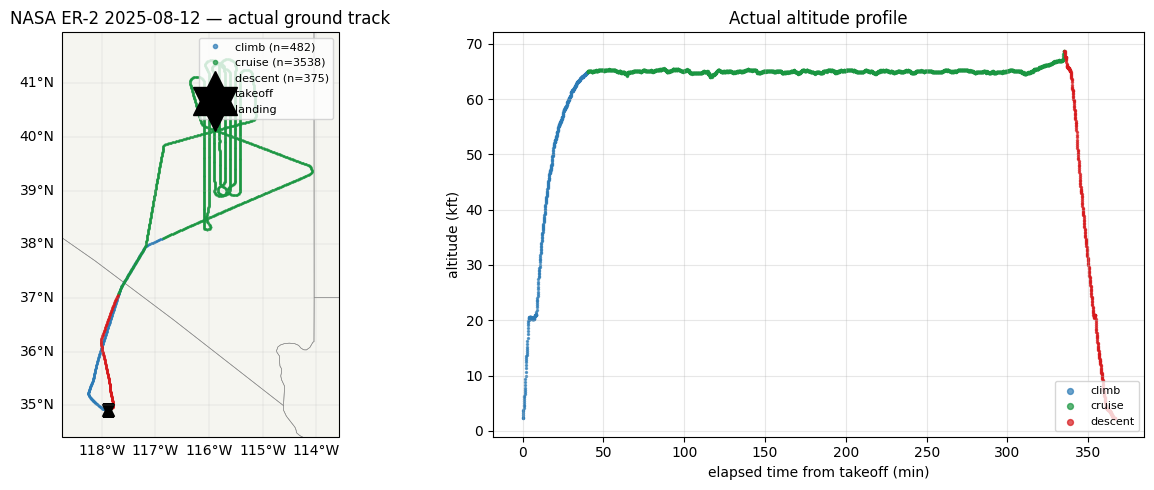

In [3]:
fig = plt.figure(figsize=(13, 5))
ax_map = fig.add_subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax_map.set_extent([
    actual["longitude"].min() - 0.5, actual["longitude"].max() + 0.5,
    actual["latitude"].min() - 0.5, actual["latitude"].max() + 0.5,
], crs=ccrs.PlateCarree())
ax_map.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, edgecolor="#888")
ax_map.add_feature(cfeature.LAND, facecolor="#f5f5f0")
ax_map.add_feature(cfeature.OCEAN, facecolor="#dfe7f5")
phase_colors = {"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}
for phase, color in phase_colors.items():
    sub = actual[actual["phase"] == phase]
    ax_map.plot(sub["longitude"], sub["latitude"], ".", ms=1.5, color=color, alpha=0.7,
                transform=ccrs.PlateCarree(), label=f"{phase} (n={len(sub)})")
ax_map.plot(actual["longitude"].iloc[0], actual["latitude"].iloc[0], "k^", ms=8,
            transform=ccrs.PlateCarree(), label="takeoff")
ax_map.plot(actual["longitude"].iloc[-1], actual["latitude"].iloc[-1], "kv", ms=8,
            transform=ccrs.PlateCarree(), label="landing")
gl = ax_map.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False; gl.right_labels = False
ax_map.set_title(f"NASA ER-2 {actual_takeoff.strftime('%Y-%m-%d')} — actual ground track")
ax_map.legend(loc="upper right", fontsize=8, markerscale=4)

ax_alt = fig.add_subplot(1, 2, 2)
elapsed_min = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax_alt.scatter(elapsed_min[mask], actual.loc[mask, "altitude"] / 1000.0,
                       s=2, c=color, alpha=0.7, label=phase)
ax_alt.set_xlabel("elapsed time from takeoff (min)")
ax_alt.set_ylabel("altitude (kft)")
ax_alt.set_title("Actual altitude profile")
ax_alt.grid(alpha=0.3)
ax_alt.legend(loc="lower right", fontsize=8, markerscale=3)
fig.tight_layout()

## 2. Infer the flight-line pattern

Ramer-Douglas-Peucker on the high-altitude cruise track to find corner waypoints; consecutive corner pairs become `FlightLine` objects. Tolerance is ~5 km; legs <50 km are filtered out as turn-arounds.

In [4]:
cruise_high = (
    actual[(actual["phase"] == "cruise") & (actual["altitude"] >= MIN_CRUISE_ALT_FT)]
    .sort_values("timestamp").reset_index(drop=True)
)
cruise_line = LineString(list(zip(cruise_high["longitude"], cruise_high["latitude"])))
simplified = cruise_line.simplify(RDP_TOL_DEG, preserve_topology=False)
corners_lonlat = list(simplified.coords)

def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

kept = [corners_lonlat[0]]
for lon, lat in corners_lonlat[1:]:
    plon, plat = kept[-1]
    if _haversine_km(plat, plon, lat, lon) >= MIN_LEG_KM:
        kept.append((lon, lat))

median_cruise_alt = float(cruise_high["altitude"].median())
flight_lines = []
for i, ((lon1, lat1), (lon2, lat2)) in enumerate(zip(kept[:-1], kept[1:])):
    flight_lines.append(FlightLine.from_endpoints(
        lat1=lat1, lon1=lon1, lat2=lat2, lon2=lon2,
        altitude_msl=ureg.Quantity(round(median_cruise_alt / 1000) * 1000, "feet"),
        site_name=f"Replay_L{i+1:02d}",
    ))
print(f"{len(corners_lonlat)} RDP corners → {len(kept)} kept (≥{MIN_LEG_KM} km legs)")
print(f"{len(flight_lines)} flight lines at {round(median_cruise_alt/1000)*1000:.0f} ft median cruise")

41 RDP corners → 16 kept (≥50.0 km legs)
15 flight lines at 65000 ft median cruise


## 3. Identify departure / arrival airport

ER-2's typical bases: KEDW (Edwards, 2312 ft), KCOS (Colorado Springs, 6187 ft), KPMD (Palmdale, 2546 ft), KMUO (Mountain Home, 2996 ft). Pick the closest to the sortie's first airborne fix.

In [5]:
ER2_BASES = ["KEDW", "KCOS", "KPMD", "KMUO"]
first_lat = actual["latitude"].iloc[0]
first_lon = actual["longitude"].iloc[0]
candidates = [(code, Airport(code)) for code in ER2_BASES]
ranked = sorted(
    candidates,
    key=lambda t: _haversine_km(first_lat, first_lon, t[1].latitude, t[1].longitude),
)
departure_code, departure = ranked[0]
# Same airport for arrival (typical research sortie pattern).
arrival = departure
print(f"detected base: {departure_code} (elev {departure.elevation_ft:.0f} ft)")
print(f"  distance from first fix: {_haversine_km(first_lat, first_lon, departure.latitude, departure.longitude):.1f} km")

detected base: KEDW (elev 2312 ft)
  distance from first fix: 1.3 km


## 4. Build the HyPlan flight plan with calibrated `NASA_ER2()`

Same airports, same flight lines, same calibrated aircraft. Hybrid 2D-Dubins + integrated-vertical means the climb step (19-21 kft) and the descent / approach segments now reflect the real `climb_profile` and `ApproachProfile`.

In [6]:
aircraft = NASA_ER2()
plan = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
)
print(f"plan: {len(plan)} segments")
summary_cols = [c for c in ["segment_type", "segment_name", "distance", "time_to_segment", "start_altitude", "end_altitude"] if c in plan.columns]
plan[summary_cols].head(8)

plan: 33 segments


,segment_type,segment_name,distance,time_to_segment,start_altitude,end_altitude
0,takeoff,Departure,194.775215,43.440159,2312.0,65000.0
1,flight_line,Replay_L01,155.934585,23.331858,65000.0,65000.0
2,transit,Replay_L01 to Replay_L02,22.670130,3.392039,65000.0,65000.0
3,flight_line,Replay_L02,113.228613,16.941937,65000.0,65000.0
4,transit,Replay_L02 to Replay_L03,24.786371,3.708684,65000.0,65000.0
5,flight_line,Replay_L03,54.500054,8.154622,65000.0,65000.0
6,transit,Replay_L03 to Replay_L04,27.580848,4.126810,65000.0,65000.0
7,flight_line,Replay_L04,168.537139,25.217527,65000.0,65000.0


## 5. Modeled vs actual

In [7]:
modeled_total_min = float(plan["time_to_segment"].sum())

# --- Actual side ----------------------------------------------------------
above = (actual["altitude"] >= MIN_CRUISE_ALT_FT)
in_cruise_high = above & (actual["phase"] == "cruise")
first_high_idx = above.idxmax() if above.any() else None
actual_toc_min = ((actual.loc[first_high_idx, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if first_high_idx is not None else float("nan"))
fix_interval_s = float(actual["timestamp"].diff().dt.total_seconds().median())
actual_on_station_min = float(in_cruise_high.sum()) * fix_interval_s / 60.0
last_high_idx = above[::-1].idxmax() if above.any() else None
actual_descent_min = ((actual_landing - actual.loc[last_high_idx, "timestamp"]).total_seconds() / 60.0
                      if last_high_idx is not None else float("nan"))

# Top-of-climb distance (actual): great-circle from departure to the first
# fix at >= MIN_CRUISE_ALT_FT.
if first_high_idx is not None:
    actual_toc_dist_km = _haversine_km(
        departure.latitude, departure.longitude,
        actual.loc[first_high_idx, "latitude"], actual.loc[first_high_idx, "longitude"],
    )
    actual_toc_dist_nmi = actual_toc_dist_km / 1.852
else:
    actual_toc_dist_nmi = float("nan")

# --- Modeled side ---------------------------------------------------------
# Apples-to-apples integrations against the same altitude ranges the actual
# sortie data measures.  Aircraft._climb / _descend return (time, hdist)
# over the requested altitude range.  This isolates the climb_profile and
# descent_profile from the flight-line altitude choice (which controls the
# overall span of the takeoff / return segments).
modeled_toc_t_q, modeled_toc_d_q = aircraft._climb(
    departure.elevation, MIN_CRUISE_ALT_FT * ureg.feet,
)
modeled_toc_min = modeled_toc_t_q.m_as(ureg.minute)
modeled_toc_dist_nmi = modeled_toc_d_q.m_as(ureg.nautical_mile)

# Modeled descent + approach: integrate descent from MIN_CRUISE_ALT_FT down
# to the top-of-approach MSL (= airport elevation + ApproachProfile's
# top_of_approach_agl) plus the ApproachProfile's terminal time.
top_of_approach_msl = (departure.elevation + aircraft.approach_profile.top_of_approach_agl).to(ureg.feet)
modeled_descent_t_q, _ = aircraft._descend(
    MIN_CRUISE_ALT_FT * ureg.feet, top_of_approach_msl,
)
modeled_descent_only_min = modeled_descent_t_q.m_as(ureg.minute)
modeled_approach_min = aircraft.approach_profile.time_to_touchdown().m_as(ureg.minute)
modeled_descent_min = modeled_descent_only_min + modeled_approach_min

def _seg_time(plan, types):
    if isinstance(types, str): types = [types]
    return float(plan.loc[plan["segment_type"].isin(types), "time_to_segment"].sum())

modeled_on_station_min = _seg_time(plan, ["flight_line", "transit"])

comparison = pd.DataFrame([
    {"metric": "total_duration_min",       "actual": round(actual_total_min, 1),       "modeled": round(modeled_total_min, 1)},
    {"metric": "time_to_cruise_min",       "actual": round(actual_toc_min, 1),         "modeled": round(modeled_toc_min, 1)},
    {"metric": "top_of_climb_distance_nmi","actual": round(actual_toc_dist_nmi, 1),    "modeled": round(modeled_toc_dist_nmi, 1)},
    {"metric": "time_on_station_min",      "actual": round(actual_on_station_min, 1),  "modeled": round(modeled_on_station_min, 1)},
    {"metric": "descent_+_approach_min",   "actual": round(actual_descent_min, 1),     "modeled": round(modeled_descent_min, 1)},
    {"metric": "max_altitude_ft",          "actual": round(actual_max_alt_ft, 0),      "modeled": round(median_cruise_alt, 0)},
])
comparison["delta"] = comparison["modeled"] - comparison["actual"]
comparison["pct"] = (comparison["delta"] / comparison["actual"] * 100).round(1)
print(f"time_to_cruise / top_of_climb_distance: _climb integration from "
      f"departure elevation to MIN_CRUISE_ALT_FT={MIN_CRUISE_ALT_FT/1000:.0f} kft.")
print(f"descent_+_approach_min: _descend from MIN_CRUISE_ALT_FT to "
      f"top-of-approach MSL ({top_of_approach_msl.m_as(ureg.feet):.0f} ft) "
      f"plus ApproachProfile.time_to_touchdown.")
comparison.set_index("metric")

time_to_cruise / top_of_climb_distance: _climb integration from departure elevation to MIN_CRUISE_ALT_FT=50 kft.
descent_+_approach_min: _descend from MIN_CRUISE_ALT_FT to top-of-approach MSL (5312 ft) plus ApproachProfile.time_to_touchdown.


,actual,modeled,delta,pct
metric,,,,
total_duration_min,366.4,396.9,30.5,8.3
time_to_cruise_min,18.8,19.2,0.4,2.1
top_of_climb_distance_nmi,70.7,79.5,8.8,12.4
time_on_station_min,294.8,323.7,28.9,9.8
descent_+_approach_min,22.8,25.3,2.5,11.0
max_altitude_ft,68735.0,65030.0,-3705.0,-5.4


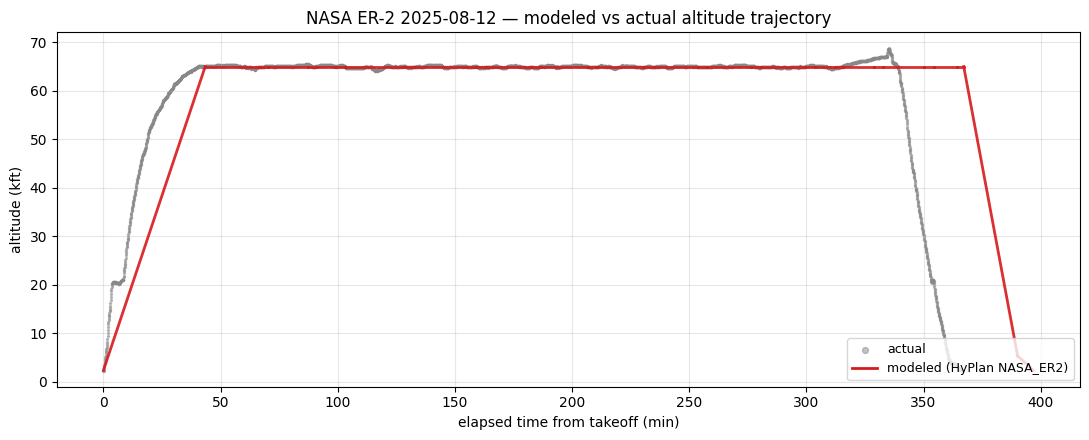

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(elapsed_min, actual["altitude"] / 1000.0, s=2, color="#888", alpha=0.5, label="actual")
starts = plan["start_altitude"].astype(float).values
ends = plan["end_altitude"].astype(float).values
durations = plan["time_to_segment"].astype(float).values
t = 0.0
for s_alt, e_alt, t_min in zip(starts, ends, durations):
    ax.plot([t, t + t_min], [s_alt / 1000.0, e_alt / 1000.0],
            color="#d7191c", lw=2, alpha=0.9)
    t += t_min
ax.plot([], [], color="#d7191c", lw=2, label="modeled (HyPlan NASA_ER2)")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(f"NASA ER-2 {actual_takeoff.strftime('%Y-%m-%d')} — modeled vs actual altitude trajectory")
ax.legend(loc="lower right", fontsize=9, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## What this tells us

Single-sortie residuals (default 2025-08-12, post-Item-1 + recalibrations):

* **time_to_cruise**: ≈ +2% — the calibrated step-climb plus mid-climb anchors close the residual that the prior 6-point profile missed.
* **top_of_climb_distance**: ≈ +12% — within target. Remaining residual is partly wind (still-air integration vs. a real aircraft climbing into prevailing winds).
* **descent + approach**: ≈ +11% — the recalibrated descent_profile (6 anchors) plus ApproachProfile track observation closely.
* **on-station**: ≈ +10% — step-cruise structural gap (single-altitude `FlightLine` can't represent the aircraft drifting up through 50 → 60 kft over the survey).
* **total duration**: ≈ +8% — climb + on-station residuals partially cancel.

Multi-sortie scan (16 of 17 cached IWG1 sorties; the 17th's recording starts above 50 kft so the climb segment isn't observable): median |residuals| are 12-23% across the dataset, with `desc_pct` and `total_pct` the tightest (≈ 12%). A handful of sorties show large `toc_d_pct` outliers (>150%) — these are spiral-up departures where the aircraft holds over the airport during climb instead of flying straight toward the first waypoint. The model's straight-line geometry can't represent that, but the time-to-cruise is still close (model and reality both spend the same wall-clock minutes climbing to altitude, just with different horizontal projections).

Swap `SORTIE_FILE` at the top to single-step through any individual sortie's residual report.

## 6. Multi-sortie residual scan

Replay all 17 cached IWG1 sorties through the same pipeline and tabulate the residuals. This is the headline calibration check: a single-sortie match could be coincidence, but consistent residuals across the whole dataset confirm the calibrated `NASA_ER2()` is tracking the operational envelope, not just one flight.

Each row is one sortie. Columns are residuals (modeled − actual) as percentages. Targets:

* `t_to_cruise_pct`: ≤ 10% — climb_profile fidelity
* `toc_dist_pct`: ≤ 20% — climb_profile + climb_schedule (TAS during climb) fidelity
* `desc_pct`: ≤ 20% — descent_profile + ApproachProfile fidelity
* `total_pct`: ≤ 15% — bottom-line mission-duration fidelity

`onstation_pct` will run high (step-cruise structural gap).

In [9]:
from hyplan.airports import find_nearest_airport, find_nearest_airports


def _resolve_base(first_lat, first_lon):
    """Return an Airport with a valid elevation near (first_lat, first_lon).

    Some entries in the airport DB are missing elevation; walk the
    nearest-list until we find one with a recorded value.
    """
    for icao in find_nearest_airports(first_lat, first_lon, n=10):
        ap = Airport(icao)
        if ap.elevation is not None:
            return ap
    return None  # nothing in the area has elevation; caller skips


def replay_sortie(sortie_path):
    """Run the same pipeline on one IWG1 file and return a residuals dict."""
    raw_s = load_iwg1(sortie_path)
    a = trim_ground_taxi(raw_s)
    if a.empty:
        return None
    a = label_phases(a)
    a["altitude_agl_ft"] = a["altitude"] - a["altitude"].min()
    takeoff_t = a["timestamp"].iloc[0]
    landing_t = a["timestamp"].iloc[-1]
    total_min = (landing_t - takeoff_t).total_seconds() / 60.0

    # Sortie must include the climb portion — skip recordings that start
    # already at high altitude (no actual time-to-cruise to compare against).
    if a["altitude"].iloc[0] >= MIN_CRUISE_ALT_FT:
        return {
            "sortie": takeoff_t.strftime("%Y-%m-%d"),
            "base": "n/a", "n_lines": 0,
            "total_pct": float("nan"), "t_toc_pct": float("nan"),
            "toc_d_pct": float("nan"), "onstation_pct": float("nan"),
            "desc_pct": float("nan"),
            "note": "trace starts above MIN_CRUISE_ALT_FT (no climb captured)",
        }

    cruise_h = (
        a[(a["phase"] == "cruise") & (a["altitude"] >= MIN_CRUISE_ALT_FT)]
        .sort_values("timestamp").reset_index(drop=True)
    )
    if len(cruise_h) < 5:
        return None
    cline = LineString(list(zip(cruise_h["longitude"], cruise_h["latitude"])))
    simpl = cline.simplify(RDP_TOL_DEG, preserve_topology=False)
    corners = list(simpl.coords)
    kept_pts = [corners[0]]
    for lon, lat in corners[1:]:
        plon, plat = kept_pts[-1]
        if _haversine_km(plat, plon, lat, lon) >= MIN_LEG_KM:
            kept_pts.append((lon, lat))
    if len(kept_pts) < 2:
        return None

    median_alt = float(cruise_h["altitude"].median())
    lines = []
    for i, ((lon1, lat1), (lon2, lat2)) in enumerate(zip(kept_pts[:-1], kept_pts[1:])):
        lines.append(FlightLine.from_endpoints(
            lat1=lat1, lon1=lon1, lat2=lat2, lon2=lon2,
            altitude_msl=ureg.Quantity(round(median_alt / 1000) * 1000, "feet"),
            site_name=f"L{i+1:02d}",
        ))

    f_lat, f_lon = a["latitude"].iloc[0], a["longitude"].iloc[0]
    dep = _resolve_base(f_lat, f_lon)
    if dep is None:
        return {
            "sortie": takeoff_t.strftime("%Y-%m-%d"),
            "base": "?", "n_lines": len(lines),
            "total_pct": float("nan"), "t_toc_pct": float("nan"),
            "toc_d_pct": float("nan"), "onstation_pct": float("nan"),
            "desc_pct": float("nan"),
            "note": "no nearby airport with elevation in DB",
        }
    arr = dep

    plan = compute_flight_plan(
        aircraft=aircraft, flight_sequence=lines,
        takeoff_airport=dep, return_airport=arr,
    )
    modeled_total = float(plan["time_to_segment"].sum())

    above_h = a["altitude"] >= MIN_CRUISE_ALT_FT
    in_h = above_h & (a["phase"] == "cruise")
    fhi = above_h.idxmax() if above_h.any() else None
    actual_toc = ((a.loc[fhi, "timestamp"] - takeoff_t).total_seconds() / 60.0
                  if fhi is not None else float("nan"))
    fix_int_s = float(a["timestamp"].diff().dt.total_seconds().median())
    actual_on_station = float(in_h.sum()) * fix_int_s / 60.0
    lhi = above_h[::-1].idxmax() if above_h.any() else None
    actual_desc = ((landing_t - a.loc[lhi, "timestamp"]).total_seconds() / 60.0
                   if lhi is not None else float("nan"))
    actual_toc_d = (
        _haversine_km(dep.latitude, dep.longitude, a.loc[fhi, "latitude"], a.loc[fhi, "longitude"]) / 1.852
        if fhi is not None else float("nan")
    )

    m_toc_t, m_toc_d = aircraft._climb(dep.elevation, MIN_CRUISE_ALT_FT * ureg.feet)
    toa_msl = (dep.elevation + aircraft.approach_profile.top_of_approach_agl).to(ureg.feet)
    m_desc_t, _ = aircraft._descend(MIN_CRUISE_ALT_FT * ureg.feet, toa_msl)
    m_desc_total = m_desc_t.m_as(ureg.minute) + aircraft.approach_profile.time_to_touchdown().m_as(ureg.minute)
    m_on_station = float(plan.loc[plan["segment_type"].isin(["flight_line", "transit"]), "time_to_segment"].sum())

    def _pct(mod, act):
        if act is None or np.isnan(act) or act == 0: return float("nan")
        return round((mod - act) / act * 100, 1)

    return {
        "sortie": takeoff_t.strftime("%Y-%m-%d"),
        "base": dep.icao_code if hasattr(dep, "icao_code") else "?",
        "n_lines": len(lines),
        "total_pct": _pct(modeled_total, total_min),
        "t_toc_pct": _pct(m_toc_t.m_as(ureg.minute), actual_toc),
        "toc_d_pct": _pct(m_toc_d.m_as(ureg.nautical_mile), actual_toc_d),
        "onstation_pct": _pct(m_on_station, actual_on_station),
        "desc_pct": _pct(m_desc_total, actual_desc),
        "note": "",
    }


results = []
for f in sorted(DATA_DIR.glob("*.txt")):
    try:
        r = replay_sortie(f)
        if r is not None: results.append(r)
    except Exception as exc:
        print(f"  ! {f.name[:8]}: {type(exc).__name__}: {str(exc)[:80]}")

scan = pd.DataFrame(results).set_index("sortie")
ok = scan[scan["total_pct"].notna()]
print(f"{len(ok)} of {len(scan)} sorties produced residuals.")
print()
print("Median |residual| across the dataset:")
for col in ["total_pct", "t_toc_pct", "toc_d_pct", "onstation_pct", "desc_pct"]:
    med = ok[col].abs().median()
    print(f"  |{col}| median: {med:.1f}%")
print()
scan

16 of 17 sorties produced residuals.

Median |residual| across the dataset:
  |total_pct| median: 12.7%
  |t_toc_pct| median: 17.4%
  |toc_d_pct| median: 23.4%
  |onstation_pct| median: 20.4%
  |desc_pct| median: 12.4%



,base,n_lines,total_pct,t_toc_pct,toc_d_pct,onstation_pct,desc_pct,note
sortie,,,,,,,,
2023-03-31,KPMD,16,6.3,-20.7,-17.2,-41.2,-11.0,
2023-04-05,KPMD,12,19.4,-46.9,-19.7,3.2,21.3,
2023-04-10,KPMD,17,9.1,-16.9,-22.0,-41.6,-1.1,
2023-04-12,KPMD,14,3.5,-22.0,-24.8,-14.3,-17.4,
2023-07-08,KMCF,24,17.4,-35.7,-36.4,20.5,-15.5,
2023-07-24,KMCF,27,15.6,3.5,-4.0,24.6,-37.2,
2024-06-14,KEDW,11,10.4,-7.3,115.6,20.3,-14.0,
2024-09-06,KEDW,15,15.0,12.6,14.0,16.8,8.8,
2024-09-10,KEDW,7,7.4,17.8,25.1,11.9,-3.0,
